# 18 — Clima, diferencia de volumen y desplazamiento de la producción teórica

Alcance: GAITANA. La pregunta no es sólo si el clima tiene una correlación con producción, sino si ayuda a explicar el error de la teoría y el momento del corte. Se separan cobertura, asociación exploratoria y aporte predictivo (19). No se infiere causalidad.

Se incorpora lluvia registrada y se mantienen temperatura, humedad y radiación. La radiación es la medida disponible relacionada con exposición solar; no se inventa otra variable de luminosidad. La lluvia se conserva en unidades de la fuente, sin afirmar milímetros ni convertirla a una cantidad física no documentada. Su suma supone lecturas de cantidad por intervalo (campo RAIN, no tasa); debe confirmarse con la estación. Se auditan negativos, huecos y frecuencia antes de interpretarla.

Todas las ventanas predictoras terminan antes del lunes de emisión. Las relaciones principales del EDA usan objetivos cerrados antes del 7 de julio de 2025; los datos posteriores se reservan a las comparaciones temporales. Las diferencias pueden estar confundidas por temporada, manejo, variedad y composición de cohortes.

Clima bruto por finca: 2021-01-01 00:00:00 2026-09-21 00:00:00 última medición válida: 2026-09-21 00:00:00


,registros,validos,conflictos,lluvia_faltante,lluvia_negativa
fecha,,,,,
2021,15354,14281,11,0,0
2022,16736,16649,0,0,0
2023,16387,16311,75,0,0
2024,17204,16925,0,3,0
2025,17471,17436,0,0,0
2026,10242,9949,272,0,0


Registros diarios típicos históricos: 48.0 ; lluvia diaria requiere 80 % de esa cobertura.


,mediciones,lluvia_registros,lluvia
count,2085.000000,2085.000000,1828.000000
mean,43.909353,43.907914,1.922237
std,10.527951,10.527596,4.277142
min,1.000000,1.000000,0.000000
25%,47.000000,47.000000,0.000000
50%,48.000000,48.000000,0.000000
75%,48.000000,48.000000,1.770000
max,48.000000,48.000000,44.600000


,temperatura_media14_clima,temperatura_cambio7_28_clima,humedad_media14_clima,humedad_cambio7_28_clima,radiacion_media14_clima,radiacion_cambio7_28_clima,lluvia_suma7_clima,lluvia_suma28_clima,lluvia_dias7_clima,cobertura_dias7_clima,cobertura_dias28_clima
origen,,,,,,,,,,,
2026-01,1.0,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.0,1.0
2026-02,0.5,0.5,0.5,0.5,0.5,0.5,0.25,0.25,0.25,1.0,1.0
2026-03,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.0,1.0
2026-04,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.0,1.0
2026-05,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.0,1.0
2026-06,0.6,0.4,0.6,0.4,0.6,0.4,0.80,0.20,0.80,1.0,1.0
2026-07,1.0,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.0,1.0
2026-08,1.0,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.0,1.0
2026-09,1.0,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.0,1.0


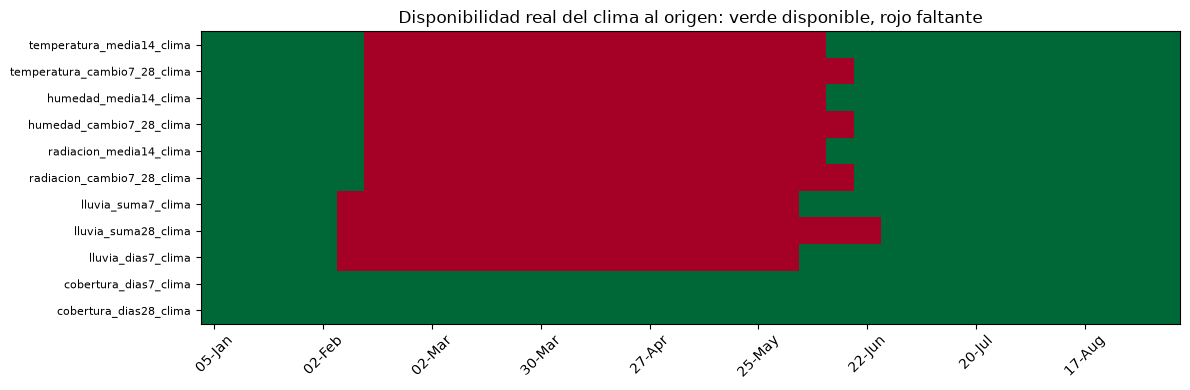

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Datos_analiticos_proyecto').exists())
DATA=ROOT/'Datos_analiticos_proyecto';OUT=DATA/'revision_clima_finca';OUT.mkdir(exist_ok=True)
FIG=ROOT/'Trabajo escrito/Figuras_resultados';FIG.mkdir(exist_ok=True)
KEY=['finca','producto','color','variedad']
raw=pd.read_parquet(DATA/'clima_limpio.parquet')
raw=raw.loc[raw.finca.eq('GAITANA')].copy()
print('Clima bruto por finca:',raw.fecha.min(),raw.fecha.max(),'última medición válida:',raw.loc[raw.medicion_valida,'fecha'].max())
audit=raw.groupby(raw.fecha.dt.year).agg(registros=('fecha','size'),validos=('medicion_valida','sum'),conflictos=('conflicto_entre_ediciones','sum'),lluvia_faltante=('lluvia',lambda s:s.isna().sum()),lluvia_negativa=('lluvia',lambda s:s.lt(0).sum()))
display(audit)
cl=raw.loc[raw.medicion_valida].copy()
cl['lluvia_util']=cl.lluvia.where(cl.lluvia.ge(0))
daily=cl.groupby('fecha').agg(temperatura=('temperatura','mean'),humedad=('humedad','mean'),radiacion=('radiacion','mean'),lluvia=('lluvia_util',lambda s:s.sum(min_count=1)),mediciones=('instante','size'),lluvia_registros=('lluvia_util','count')).sort_index()
cal=pd.date_range(raw.fecha.min(),max(raw.fecha.max(),pd.Timestamp('2026-09-07')),freq='D')
daily=daily.reindex(cal).rename_axis('fecha')
# Número típico de registros válidos al día en el histórico previo al periodo de evaluación.
esperados=float(daily.loc[daily.index<'2026-01-01','mediciones'].median())
assert esperados>0
daily['dia_cubierto']=daily.mediciones.ge(.8*esperados)
daily['lluvia']=daily.lluvia.where(daily.dia_cubierto&daily.lluvia_registros.ge(.8*esperados))
print('Registros diarios típicos históricos:',esperados,'; lluvia diaria requiere 80 % de esa cobertura.')
display(daily[['mediciones','lluvia_registros','lluvia']].describe())
def crear_features(d):
    out=pd.DataFrame(index=d.index)
    for col in ['temperatura','humedad','radiacion']:
        v=d[col].where(d.dia_cubierto).shift(1)
        out[col+'_media14_clima']=v.rolling(14,min_periods=10).mean()
        out[col+'_cambio7_28_clima']=v.rolling(7,min_periods=5).mean()-v.rolling(28,min_periods=21).mean()
    r=d.lluvia.shift(1)
    out['lluvia_suma7_clima']=r.rolling(7,min_periods=7).sum()
    out['lluvia_suma28_clima']=r.rolling(28,min_periods=28).sum()
    out['lluvia_dias7_clima']=r.gt(0).where(r.notna()).rolling(7,min_periods=7).sum()
    out['cobertura_dias7_clima']=d.dia_cubierto.shift(1).rolling(7,min_periods=7).mean()
    out['cobertura_dias28_clima']=d.dia_cubierto.shift(1).rolling(28,min_periods=28).mean()
    return out.rename_axis('origen').reset_index().assign(finca='GAITANA')
features=crear_features(daily)
alterado=daily.copy();fecha_cambio=pd.Timestamp('2026-02-02')
alterado.loc[alterado.index>=fecha_cambio,['temperatura','humedad','radiacion','lluvia']]=999999
prueba=crear_features(alterado)
pd.testing.assert_frame_equal(features.loc[features.origen.le(fecha_cambio)],prueba.loc[prueba.origen.le(fecha_cambio)])
features.to_parquet(OUT/'features_clima_ampliado.parquet',index=False)
daily.reset_index().to_parquet(OUT/'clima_diario_auditado.parquet',index=False)
base=pd.read_parquet(DATA/'modelo_con_proyecciones_teoricas/base_analitica_proyecciones.parquet')
base=base.merge(features,on=['finca','origen'],how='left',validate='many_to_one')
weather=[c for c in features if c not in ['finca','origen']]
coverage=base.loc[base.origen.dt.year.eq(2026)].drop_duplicates(['finca','origen']).set_index('origen')[weather].notna()
display(coverage.groupby(coverage.index.to_period('M')).mean())
fig,ax=plt.subplots(figsize=(12,4));ax.imshow(coverage.T,aspect='auto',interpolation='nearest',cmap='RdYlGn',vmin=0,vmax=1)
ax.set_yticks(range(len(weather)),weather,fontsize=8);ticks=np.arange(0,len(coverage),4);ax.set_xticks(ticks,[coverage.index[i].strftime('%d-%b') for i in ticks],rotation=45);ax.set_title('Disponibilidad real del clima al origen: verde disponible, rojo faltante');fig.tight_layout();fig.savefig(FIG/'clima_cobertura_origen.png',dpi=170);plt.show()


## 1. Clima y error de volumen: comparar dentro de cada serie

Se estudia (real − teoría) / media4 sólo cuando la teoría está completa y la referencia es positiva. El escalamiento evita que series grandes dominen por unidades. Se calcula Spearman dentro de cada producto/color/variedad y horizonte, con al menos veinte pares y variación real de ambos valores. Se informa la mediana entre series y su soporte; no se trata cada variedad como una medición meteorológica independiente. No se escogen rezagos por el mejor resultado de 2026.

Los cuatro indicadores principales se fijan antes del análisis: temperatura, humedad y radiación medias de catorce días y lluvia registrada en veintiocho días.

series  pares  rho_mediana       q25  \
horizonte variable                                                          
1.0       humedad_media14_clima         108   6639    -0.047162 -0.191877   
          lluvia_suma28_clima            91   4412     0.064348 -0.074817   
          radiacion_media14_clima       108   6639     0.035936 -0.131482   
          temperatura_media14_clima     108   6639    -0.030487 -0.149895   
2.0       humedad_media14_clima         104   6745    -0.077514 -0.212853   
          lluvia_suma28_clima            94   4611     0.049625 -0.101281   
          radiacion_media14_clima       104   6745     0.022947 -0.147766   
          temperatura_media14_clima     104   6745    -0.044370 -0.175081   
3.0       humedad_media14_clima         102   6729    -0.125874 -0.213410   
          lluvia_suma28_clima            91   4559     0.035915 -0.125571   
          radiacion_media14_clima       102   6729     0.058988 -0.092856   
          temperatura_media14_clima     102   6729    -0.069237 -0.228912   
4.0       humedad_media14_clima          98   6584    -0.107621 -0.244697   
          lluvia_suma28_clima            90   4493     0.029908 -0.110570   
          radiacion_media14_clima        98   6584     0.069308 -0.078964   
          temperatura_media14_clima      98   6584    -0.078577 -0.230024   
5.0       humedad_media14_clima          98   6420    -0.105274 -0.275157   
          lluvia_suma28_clima            87   4298     0.032020 -0.126121   
          radiacion_media14_clima        98   6420     0.049265 -0.046634   
          temperatura_media14_clima      98   6420    -0.098491 -0.255729   

                                          q75  
horizonte variable                             
1.0       humedad_media14_clima      0.097610  
          lluvia_suma28_clima        0.215301  
          radiacion_media14_clima    0.150148  
          temperatura_media14_clima  0.141323  
2.0       humedad_media14_clima      0.105273  
          lluvia_suma28_clima        0.217386  
          radiacion_media14_clima    0.182979  
          temperatura_media14_clima  0.089435  
3.0       humedad_media14_clima      0.070358  
          lluvia_suma28_clima        0.221934  
          radiacion_media14_clima    0.181191  
          temperatura_media14_clima  0.115448  
4.0       humedad_media14_clima      0.023761  
          lluvia_suma28_clima        0.210626  
          radiacion_media14_clima    0.188558  
          temperatura_media14_clima  0.137480  
5.0       humedad_media14_clima      0.040943  
          lluvia_suma28_clima        0.198748  
          radiacion_media14_clima    0.221402  
          temperatura_media14_clima  0.128972

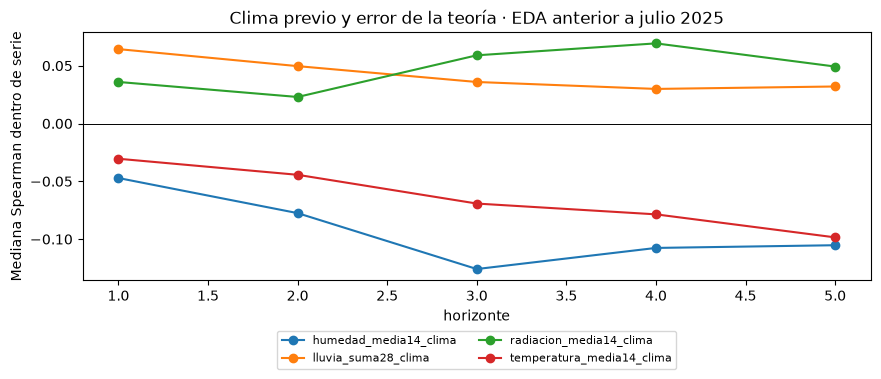

In [2]:
variables=['temperatura_media14_clima','humedad_media14_clima','radiacion_media14_clima','lluvia_suma28_clima']
eda=base.loc[(base.semana_objetivo+pd.Timedelta(days=7)).le(pd.Timestamp('2025-07-07'))&base.curva_completa&base.y.notna()&base.media_4.gt(0)].copy()
eda['error_relativo']=(eda.y-eda.teoria_modelo)/eda.media_4
rows=[]
for keys,g in eda.groupby(KEY+['horizonte']):
    for v in variables:
        t=g[[v,'error_relativo']].dropna()
        if len(t)>=20 and t[v].nunique()>2 and t.error_relativo.nunique()>2:
            rows.append(dict(zip(KEY+['horizonte'],keys))|{'variable':v,'n':len(t),'rho':t[v].corr(t.error_relativo,method='spearman')})
corr=pd.DataFrame(rows)
res=corr.groupby(['horizonte','variable']).agg(series=('rho','size'),pares=('n','sum'),rho_mediana=('rho','median'),q25=('rho',lambda s:s.quantile(.25)),q75=('rho',lambda s:s.quantile(.75)))
display(res)
fig,ax=plt.subplots(figsize=(9,4));res.rho_mediana.unstack().plot(ax=ax,marker='o');ax.axhline(0,color='black',lw=.7);ax.set_ylabel('Mediana Spearman dentro de serie');ax.set_title('Clima previo y error de la teoría · EDA anterior a julio 2025');ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.18),ncol=2);fig.tight_layout();fig.savefig(FIG/'clima_error_teoria.png',dpi=170);plt.show()


## 2. ¿Hay un desplazamiento del corte respecto a la teoría?

Se requieren cinco horizontes con real y teoría completos y totales positivos. Para cada origen/serie se calcula el centro de producción de la ventana: promedio de la posición semanal (0 a 4), ponderado por tallos. **Centro real − centro teórico > 0** significa producción relativamente más tardía dentro de esas cinco semanas; negativo, más temprana. No demuestra un retraso fisiológico ni mide lo ocurrido fuera de la ventana. Distintas cohortes y faltantes de cobertura pueden afectar este indicador.

Se separa desplazamiento de volumen total. Para relacionarlo con el clima se agregan las series al origen y se seleccionan orígenes espaciados al menos cinco semanas, evitando repetir ventanas objetivo superpuestas. Se publica el número de ventanas; una muestra pequeña no permite afirmar un efecto estable.

,desfase_semanas,error_volumen_relativo
count,5635.0,5635.0
mean,-0.008727,-0.063017
std,0.274616,3.58255
min,-2.117825,-0.980586
25%,-0.155278,-0.373399
50%,-0.005932,-0.183312
75%,0.142881,0.000414
max,1.826792,233.039468


,variable,ventanas_no_superpuestas,rho_desfase
0,temperatura_media14_clima,40,-0.149343
1,humedad_media14_clima,40,-0.100188
2,radiacion_media14_clima,40,0.201876
3,lluvia_suma28_clima,28,-0.092514


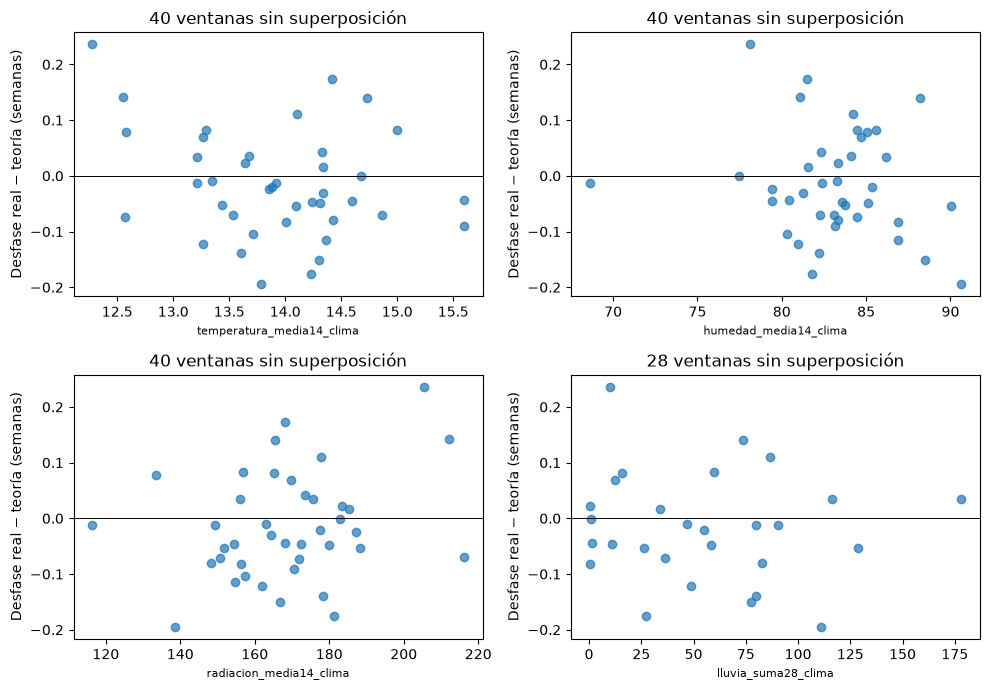

Siguiente paso: 19 compara mismos casos y cortes con/sin clima y con curva atribuida a GAITANA. Correlación no basta para afirmar utilidad predictiva.


In [3]:
lk=KEY+['origen'];completa=eda.loc[eda.groupby(lk).horizonte.transform('nunique').eq(5)].copy()
completa['real_peso']=completa.y*(completa.horizonte-1)
completa['teoria_peso']=completa.teoria_modelo*(completa.horizonte-1)
centros=completa.groupby(lk).agg(real=('y','sum'),teoria=('teoria_modelo','sum'),real_peso=('real_peso','sum'),teoria_peso=('teoria_peso','sum')).reset_index()
centros=centros.loc[centros.real.gt(0)&centros.teoria.gt(0)].copy()
centros['desfase_semanas']=centros.real_peso/centros.real-centros.teoria_peso/centros.teoria
centros['error_volumen_relativo']=(centros.real-centros.teoria)/centros.teoria
centros=centros.merge(features,on=['finca','origen'],how='left',validate='many_to_one')
display(centros[['desfase_semanas','error_volumen_relativo']].describe())
origin=centros.assign(peso_desfase=centros.desfase_semanas*centros.real).groupby('origen').agg(peso_desfase=('peso_desfase','sum'),real=('real','sum'),series=('variedad','size'))
origin['desfase_semanas']=origin.peso_desfase/origin.real
origin=origin.reset_index().merge(features,on='origen',validate='one_to_one')
selected=[];ultimo=pd.Timestamp('1900-01-01')
for fecha in sorted(origin.origen):
    if fecha>=ultimo+pd.Timedelta(weeks=5):selected.append(fecha);ultimo=fecha
independientes=origin.loc[origin.origen.isin(selected)]
associations=[]
for v in variables:
    x=independientes[[v,'desfase_semanas']].dropna()
    associations.append({'variable':v,'ventanas_no_superpuestas':len(x),'rho_desfase':x[v].corr(x.desfase_semanas,method='spearman') if len(x)>=8 and x[v].nunique()>2 else np.nan})
timing=pd.DataFrame(associations);display(timing)
fig,axs=plt.subplots(2,2,figsize=(10,7))
for ax,v in zip(axs.flat,variables):
    z=independientes[[v,'desfase_semanas']].dropna();ax.scatter(z[v],z.desfase_semanas,alpha=.7);ax.axhline(0,color='black',lw=.7);ax.set_xlabel(v,fontsize=8);ax.set_ylabel('Desfase real − teoría (semanas)');ax.set_title(f'{len(z)} ventanas sin superposición')
fig.tight_layout();fig.savefig(FIG/'clima_desfase_teoria.png',dpi=170);plt.show()
centros.to_parquet(OUT/'desfase_teoria_eda.parquet',index=False)
with pd.ExcelWriter(OUT/'eda_clima_y_desfase.xlsx') as w:
    audit.to_excel(w,sheet_name='Calidad_fuente')
    coverage.to_excel(w,sheet_name='Disponibilidad_origen')
    res.to_excel(w,sheet_name='Asociacion_volumen')
    corr.to_excel(w,sheet_name='Detalle_series',index=False)
    timing.to_excel(w,sheet_name='Asociacion_desfase',index=False)
    independientes.to_excel(w,sheet_name='Ventanas_desfase',index=False)
print('Siguiente paso: 19 compara mismos casos y cortes con/sin clima y con curva atribuida a GAITANA. Correlación no basta para afirmar utilidad predictiva.')


## 3. Incertidumbre del desplazamiento

Se remuestrean las ventanas sin superposición (1.000 veces), manteniendo cada par clima/desfase. Se informa un intervalo exploratorio del 95 % para Spearman y la mediana de desfase en el cuarto inferior/superior de cada señal. Los intervalos no corrigen búsquedas anteriores ni controlan manejo o temporada; una asociación pequeña o un intervalo que incluye cero no demuestra ausencia de efecto físico. No se transforma este EDA en una regla automática de adelanto/retraso.

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Datos_analiticos_proyecto').exists())
OUT=ROOT/'Datos_analiticos_proyecto/revision_clima_finca'
z=pd.read_excel(OUT/'eda_clima_y_desfase.xlsx',sheet_name='Ventanas_desfase')
variables=['temperatura_media14_clima','humedad_media14_clima','radiacion_media14_clima','lluvia_suma28_clima']
rng=np.random.default_rng(42);filas=[]
for v in variables:
    g=z[[v,'desfase_semanas']].dropna();rhos=[]
    if len(g)<8:continue
    for _ in range(1000):
        r=g.iloc[rng.integers(0,len(g),len(g))]
        rhos.append(r[v].corr(r.desfase_semanas,method='spearman'))
    q1,q3=g[v].quantile([.25,.75])
    filas.append({'variable':v,'ventanas':len(g),'rho':g[v].corr(g.desfase_semanas,method='spearman'),'p025':np.nanquantile(rhos,.025),'p975':np.nanquantile(rhos,.975),'desfase_mediano_cuarto_inferior':g.loc[g[v].le(q1),'desfase_semanas'].median(),'desfase_mediano_cuarto_superior':g.loc[g[v].ge(q3),'desfase_semanas'].median()})
incertidumbre=pd.DataFrame(filas);display(incertidumbre)
with pd.ExcelWriter(OUT/'eda_clima_y_desfase.xlsx',mode='a',engine='openpyxl',if_sheet_exists='replace') as writer:incertidumbre.to_excel(writer,sheet_name='Incertidumbre_desfase',index=False)
print('Las mediciones son predominantemente de 30 minutos. En las secuencias revisadas RAIN vuelve a cero entre eventos; se trata como cantidad por intervalo, conservando unidades originales pendientes de confirmación.')


,variable,ventanas,rho,p025,p975,desfase_mediano_cuarto_inferior,desfase_mediano_cuarto_superior
0,temperatura_media14_clima,40,-0.149343,-0.439271,0.217407,0.051767,-0.044502
1,humedad_media14_clima,40,-0.100188,-0.408622,0.262651,-0.027308,-0.050643
2,radiacion_media14_clima,40,0.201876,-0.094657,0.479094,-0.049286,-0.012600
3,lluvia_suma28_clima,28,-0.092514,-0.484034,0.279253,-0.000747,-0.012342


Las mediciones son predominantemente de 30 minutos. En las secuencias revisadas RAIN vuelve a cero entre eventos; se trata como cantidad por intervalo, conservando unidades originales pendientes de confirmación.
